프로젝트 1번의 B에 해당하는 코드입니다

In [2]:
#공동으로 사용되는 코드

from google.colab import drive
drive.mount('/content/drive')
import numpy as np
import matplotlib.pyplot as plt
import cv2

image_paths = [
    '/content/drive/My Drive/Colab Notebooks/D1_16.png',
    '/content/drive/My Drive/Colab Notebooks/D2_16.png',
    '/content/drive/My Drive/Colab Notebooks/D3_16.png',
    '/content/drive/My Drive/Colab Notebooks/D4_16.png',
    '/content/drive/My Drive/Colab Notebooks/D5_16.png'
]

# MSE 계산 함수
def calculate_mse(original, restored):
    return np.mean((original - restored) ** 2)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


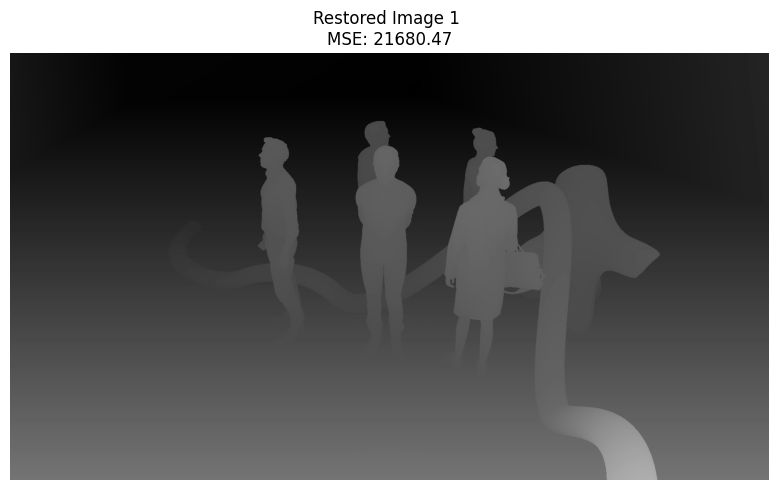

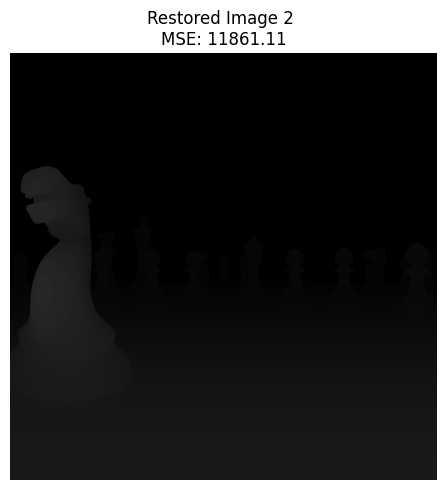

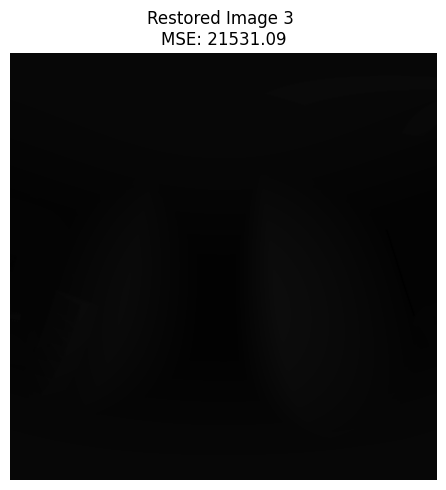

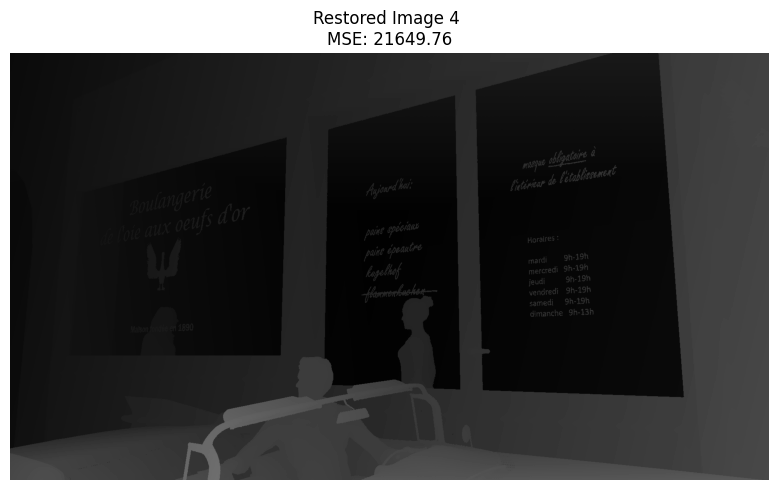

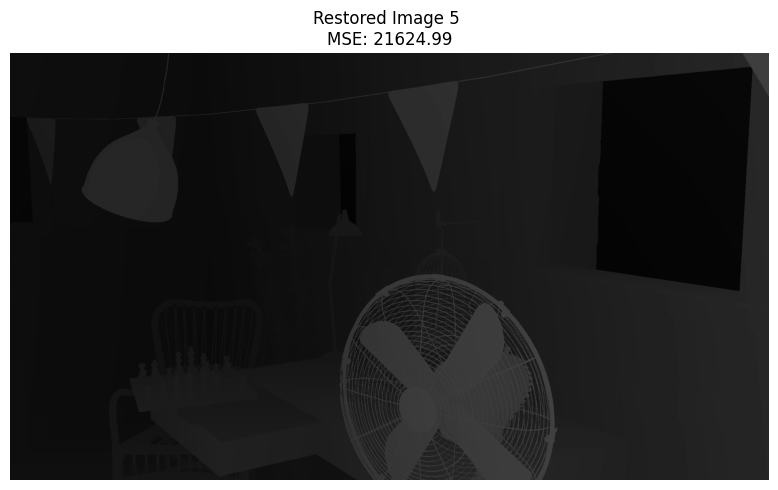

In [3]:
#방법1 복원 및 MSE계산 코드

def method_1(image_paths):
    for idx, image_path in enumerate(image_paths):

        depth_16bit = cv2.imread(image_path, cv2.IMREAD_UNCHANGED)   # 16-bit 깊이 원본 이미지
        upper_8bit = (depth_16bit >> 8).astype(np.uint8)             # 상위 8-bit 추출 이미지
        restored_16bit = (upper_8bit.astype(np.uint16) << 8)         # 다시 16-bit로 복원
        mse_value = calculate_mse(depth_16bit, restored_16bit)       # MSE 계산

# 이미지 시각화
        plt.figure(figsize=(10, 5))

# 복원된 16비트 이미지
        plt.subplot(1, 1, 1)
        plt.title(f'Restored Image {idx + 1} \nMSE: {mse_value:.2f}')
        plt.imshow(restored_16bit, cmap='gray', vmin=0, vmax=65535)
        plt.axis('off')

        plt.tight_layout()
        plt.show()

method_1(image_paths)

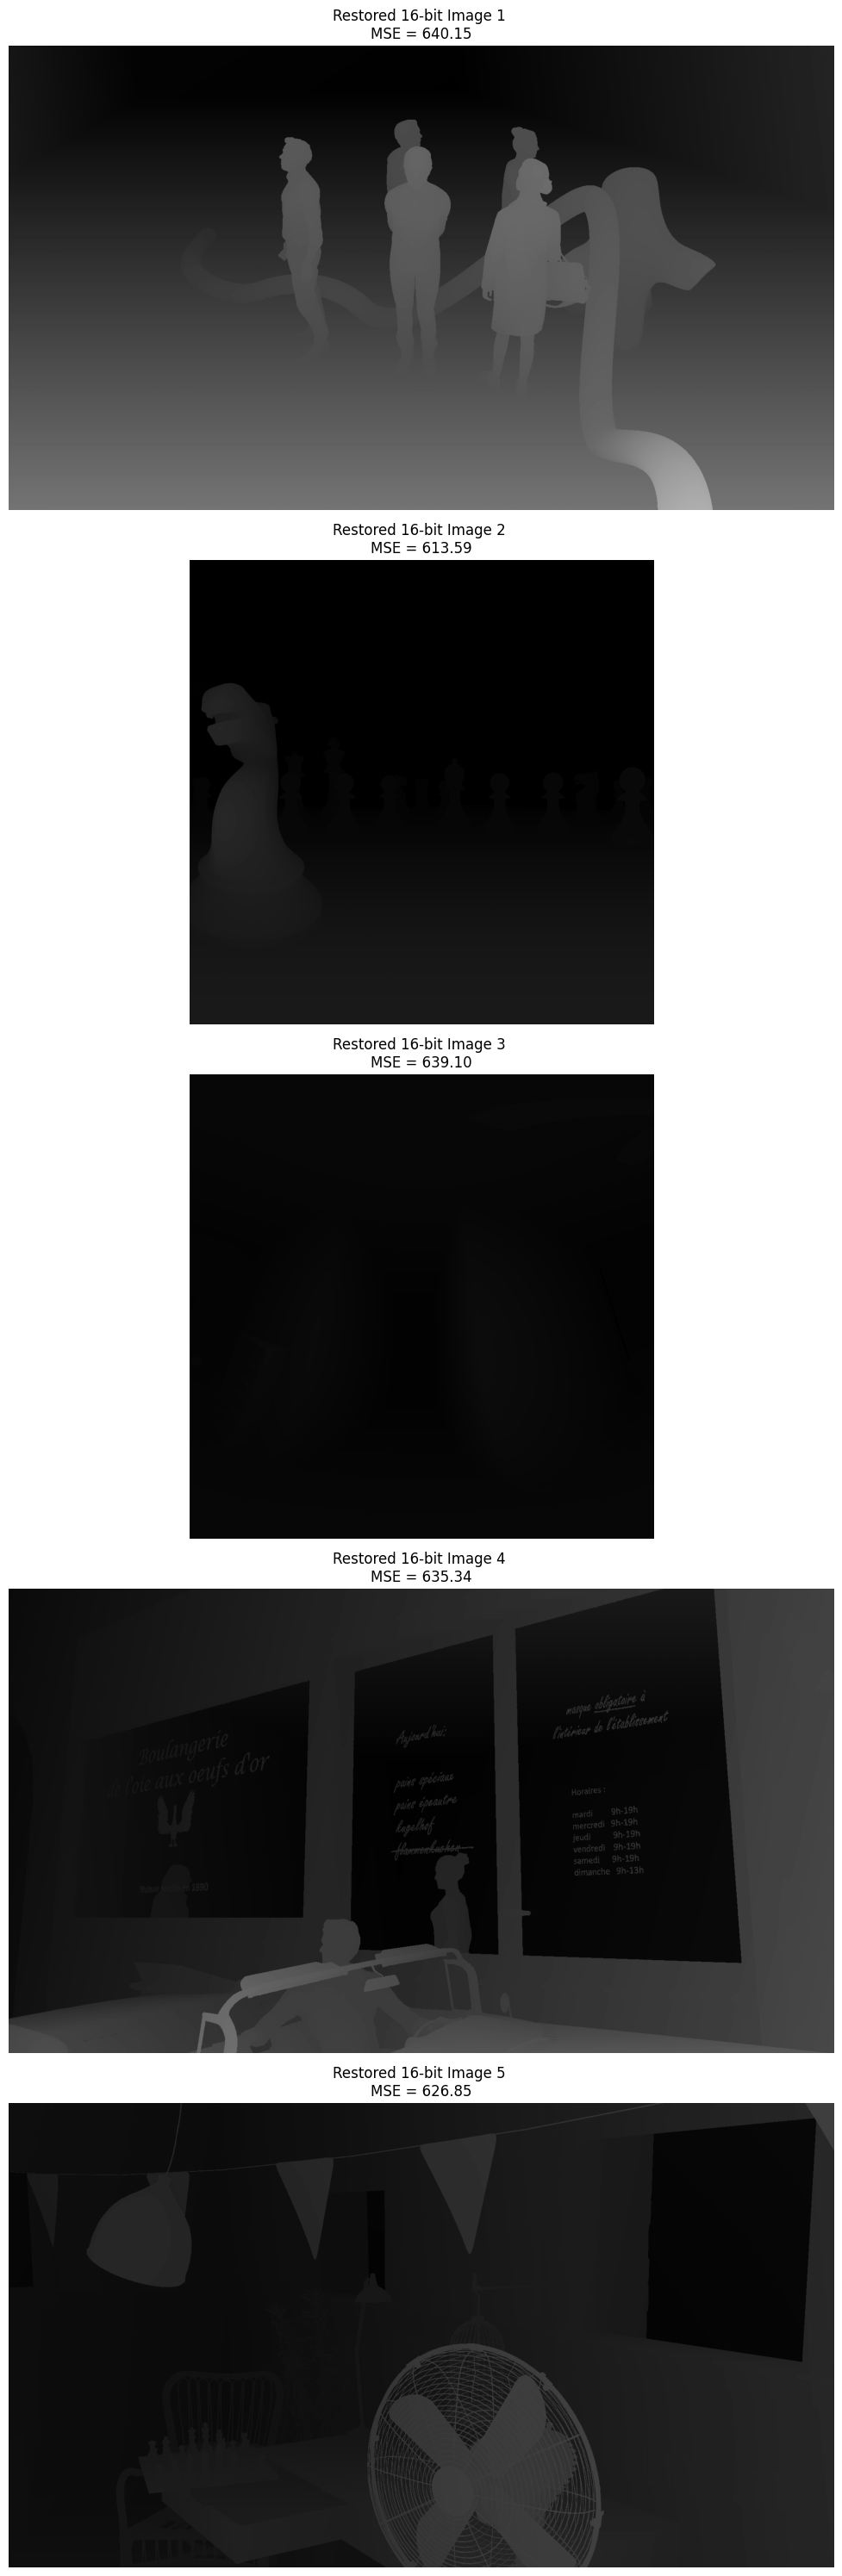

In [6]:
#방법2 복원 및 MSE 코드

#RGB 맵핑 함수
def map_to_rgb(value):
    if 0 <= value < 256:
        return (255, value, 0)                    #(255, 0~255, 0)
    elif 256 <= value < 512:
        return (255 - (value - 256), 255, 0)      #(255~0, 255, 0)
    elif 512 <= value < 768:
        return (0, 255, value - 512)              #(0, 255, 0~255)
    elif 768 <= value < 1024:
        return (0, 255 - (value - 768), 255)      #(0, 255~0, 255)
    elif 1024 <= value < 1280:
        return (value - 1024, 0, 255)             #(0~255, 0, 255)
    elif 1280 <= value < 1536:
        return (255, 0, 255 - (value - 1280))     #(255, 0, 255~0)

#RGB에서 원본 값으로 복원 함수
def map_to_value(r, g, b):
    if r == 255 and 0 <= g < 256 and b == 0:
        return g
    elif 0 <= r < 256 and g == 255 and b == 0:
        return 256 + (255 - r)
    elif r == 0 and g == 255 and 0 <= b < 256:
        return 512 + b
    elif r == 0 and 0 <= g < 256 and b == 255:
        return 768 + (255 - g)
    elif 0 <= r < 256 and g == 0 and b == 255:
        return 1024 + r
    elif r == 255 and g == 0 and 0 <= b < 256:
        return 1280 + (255 - b)

# 결과 이미지 저장 리스트
results = []

for image_path in image_paths:

    image = cv2.imread(image_path, cv2.IMREAD_UNCHANGED)                #원본 이미지 불러오기
    normalized_image = (image / 65535 * 1535).astype(np.uint16)         #각 픽셀 값 1536으로 줄이기
    rgb_image = np.zeros((*normalized_image.shape, 3), dtype=np.uint8)  #RGB 이미지 저장공간
    restored_image = np.zeros(normalized_image.shape, dtype=np.uint16)  #복원 이미지 저장공간

    # 원본에서 RGB로 변환
    for i in range(normalized_image.shape[0]):
        for j in range(normalized_image.shape[1]):
            rgb_image[i, j] = map_to_rgb(normalized_image[i, j])

    # RGB 이미지를 다시 원본 16비트 값으로 복원
    for i in range(rgb_image.shape[0]):
        for j in range(rgb_image.shape[1]):
            r, g, b = rgb_image[i, j]
            restored_image[i, j] = map_to_value(r, g, b)

    restored_image = (restored_image / 1535 * 65535).astype(np.uint16)  #복원 이미지 16비트로 설정
    mse_value = calculate_mse(image, restored_image)                    #MSE 계산
    results.append((restored_image,mse_value))                          #리스트에 원본, 복원된 이미지 저장

# 시각화
plt.figure(figsize=(20, 30))

for idx, (restored, mse) in enumerate(results):

    plt.subplot(len(results), 1, idx + 1)
    plt.title(f'Restored 16-bit Image {idx + 1} \nMSE = {mse:.2f}')
    plt.imshow(restored, cmap='gray', vmin=0, vmax=65535)
    plt.axis('off')

plt.tight_layout()
plt.show()

방법3 복원 및 MSE 코드

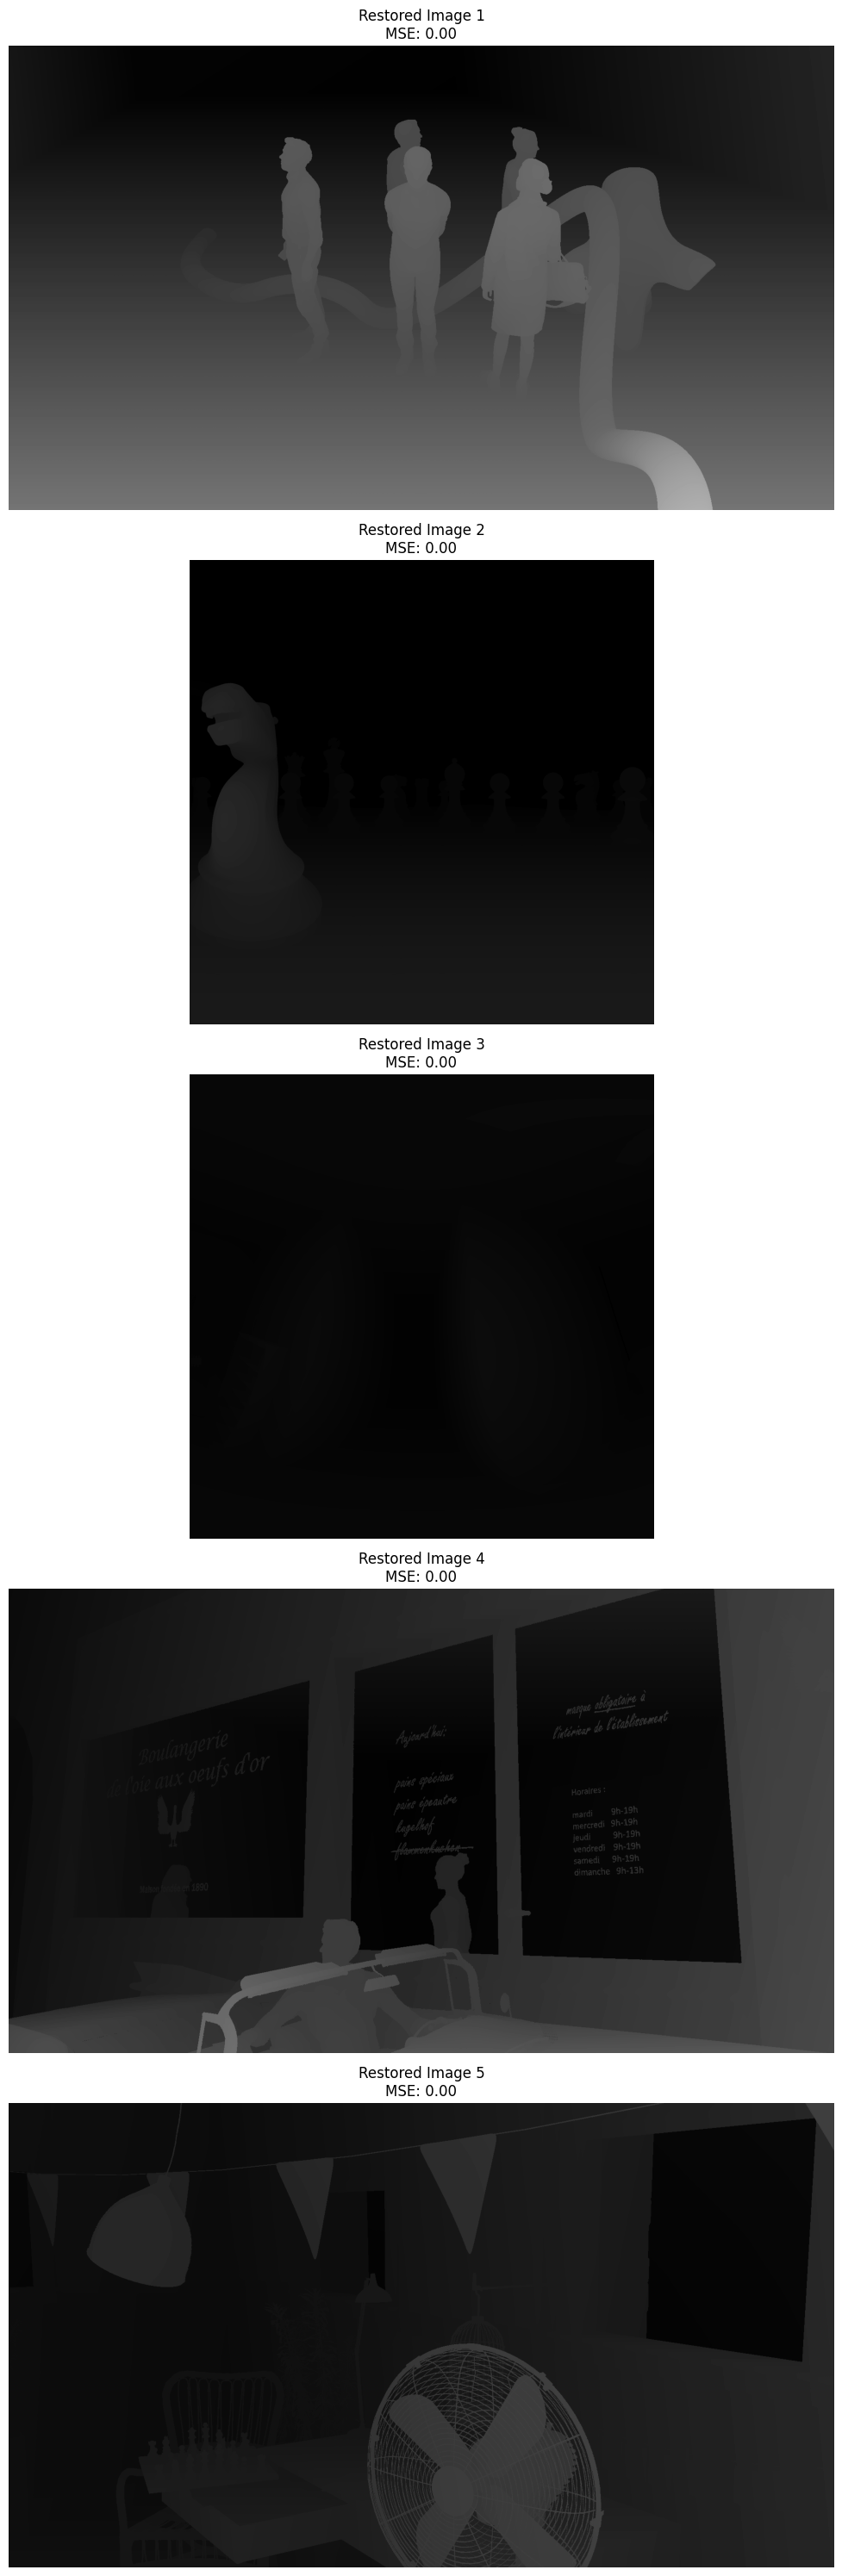

In [7]:
#16비트 이미지를 RGB로 변환하는 함수
def map_16bit_to_rgb(image_16bit):
    height, width = image_16bit.shape
    rgb_image = np.zeros((height, width, 3), dtype=np.uint8)    #RGB 이미지 저장공간

#16비트를 6비트, 6비트, 4비트로 분리 후 매핑
    for i in range(height):
        for j in range(width):
            pixel_value = image_16bit[i, j]

            r_ch = (pixel_value >> 10) & 0x3F                   #상위 6비트
            g_ch = (pixel_value >> 4) & 0x3F                    #중간 6비트
            b_ch = pixel_value & 0x0F                           #하위 4비트

#RGB 각 채널에 매핑
            rgb_image[i, j, 0] = r_ch                           #R 채널
            rgb_image[i, j, 1] = g_ch                           #G 채널
            rgb_image[i, j, 2] = b_ch                           #B 채널

    return rgb_image

#RGB 이미지를 16비트로 다시 복원하는 함수
def map_rgb_to_16bit(rgb_image):
    height, width, _ = rgb_image.shape
    restored_image = np.zeros((height, width), dtype=np.uint16) #복원 이미지 저장공간

#RGB 값을 다시 16비트 값으로 결합
    for i in range(height):
        for j in range(width):
            r_ch = rgb_image[i, j, 0]
            g_ch = rgb_image[i, j, 1]
            b_ch = rgb_image[i, j, 2]

# 각 채널 16비트로 결합
            restored_image[i, j] = (r_ch << 10) | (g_ch << 4) | b_ch

    return restored_image

# 이미지 저장 리스트
results = []

for image_path in image_paths:

    image = cv2.imread(image_path, cv2.IMREAD_UNCHANGED)        #원본 이미지 불러오기
    rgb_image = map_16bit_to_rgb(image)                         #RGB 이미지로 변환
    restored_image = map_rgb_to_16bit(rgb_image)                #다시 16비트 이미지로 복원
    mse_value = calculate_mse(image, restored_image)            #원본 이미지와 복원된 이미지의 MSE 계산

    results.append((restored_image, mse_value))

# 시각화
plt.figure(figsize=(15, 30))

for idx, (restored, mse) in enumerate(results):

    plt.subplot(len(results), 1, idx +1)
    plt.title(f'Restored Image {idx + 1}\nMSE: {mse:.2f}')
    plt.imshow(restored, cmap='gray', vmin=0, vmax=65535)
    plt.axis('off')

plt.tight_layout()
plt.show()
